In [25]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
def plot_bar_chart(df, x, hue, title, facet=None, stacked_by=None, rotate=False):
    plt.figure(figsize=(10,6))
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            # add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage (%)')
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)

            if rotate:
                ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')

            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage (%)')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=hue)
            plt.tight_layout()
            plt.show()

In [27]:
# Load the Parquet file
df = pq.read_table('data/health-indicators/can_health_indicator.parquet').to_pandas()

In [28]:
df.head()

,ref_date,geo,age_group,gender,indicators,unit,value,status,BMI,Immunization,Breastfeeding,Life_stress,Perceived_mental_health,Perceived_health,Chronic_condition,Alcohol_drug_use,Smoking
0,2018,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, very good or excellent",Number_Thousands,17374.6,None,None,None,None,None,None,very good or excellent,None,None,None
1,2018,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, very good or excellent",Percent,59.7,None,None,None,None,None,None,very good or excellent,None,None,None
2,2018,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, fair or poor",Number_Thousands,3387.0,None,None,None,None,None,None,fair or poor,None,None,None
3,2018,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, fair or poor",Percent,11.6,None,None,None,None,None,None,fair or poor,None,None,None
4,2018,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived mental health, very good or excellent",Number_Thousands,19256.0,None,None,None,None,None,very good or excellent,None,None,None,None


In [32]:
cat_cols = ['ref_date', 'geo', 'age_group', 'gender']
for col in cat_cols:
    print(df[col].unique())

[2018 2019 2020 2021 2022 2023]
['Canada (excluding territories)' 'Newfoundland and Labrador'
 'Prince Edward Island' 'Nova Scotia' 'New Brunswick' 'Quebec' 'Ontario'
 'Manitoba' 'Saskatchewan' 'Alberta' 'British Columbia']
['Total, 18 years and over' '18 to 34 years' '35 to 49 years'
 '50 to 64 years' '65 years and over']
['Both sexes' 'Males' 'Females']


# Further Data Cleaning

In [29]:
# split values in 'BMI' column on comma and only keep second part
df['BMI'] = df['BMI'].str.split(',').str[1]

# Extract Percentages & Counts

In [30]:
percentages = df[df['unit'] == 'Percent']
counts = df[df['unit'] == 'Number_Thousands']

# BMI by Geographic Location

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


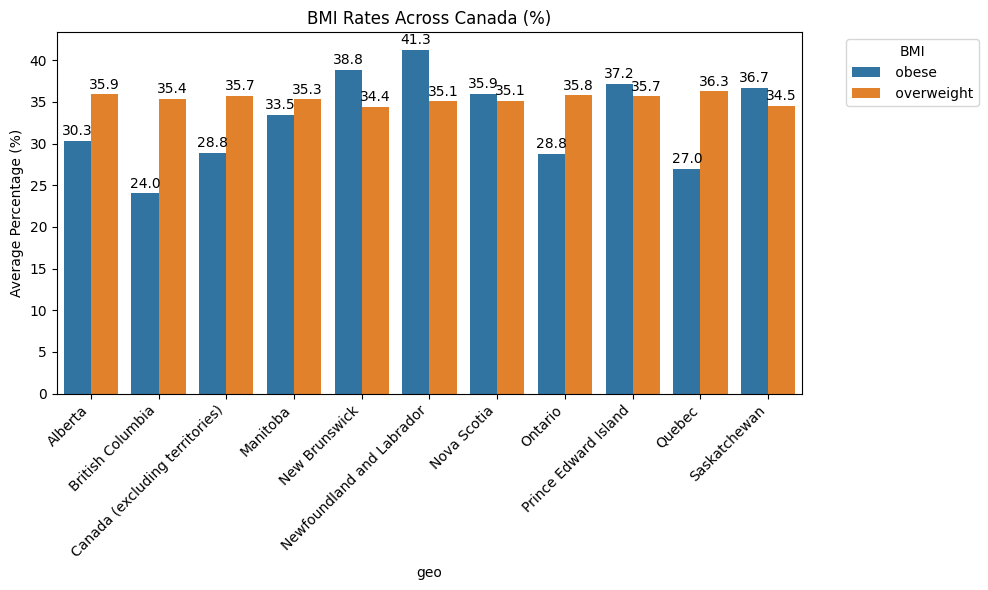

In [36]:
# plot BMI by Geographic Region
plot_bar_chart(percentages, 'geo', 'BMI', "BMI Rates Across Canada (%)", None, stacked_by=False, rotate=45)

# BMI by Gender

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


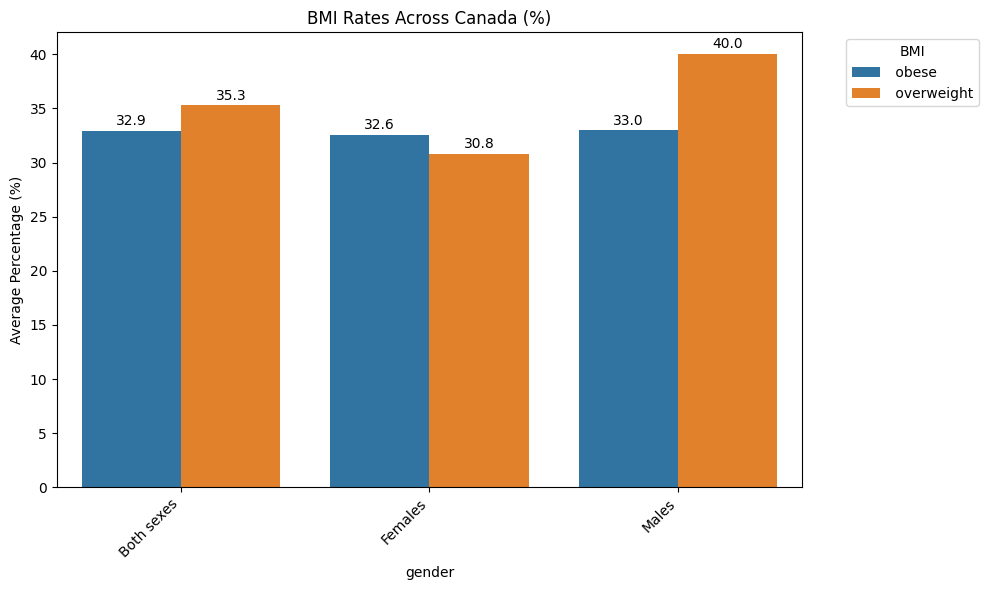

In [37]:
# plot BMI by Gender
plot_bar_chart(percentages, 'gender', 'BMI', "BMI Rates Across Canada (%)", None, stacked_by=False, rotate=45)

# Plots by Gender

In [34]:
cols_to_plot = ['Immunization','Breastfeeding','Life_stress','Perceived_mental_health','Perceived_health','Chronic_condition','Alcohol_drug_use','Smoking']

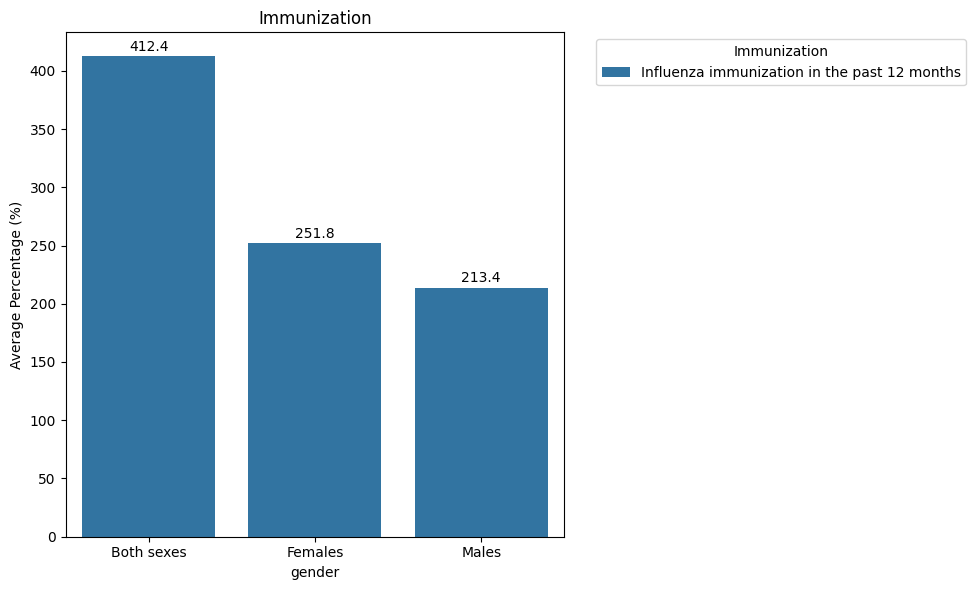

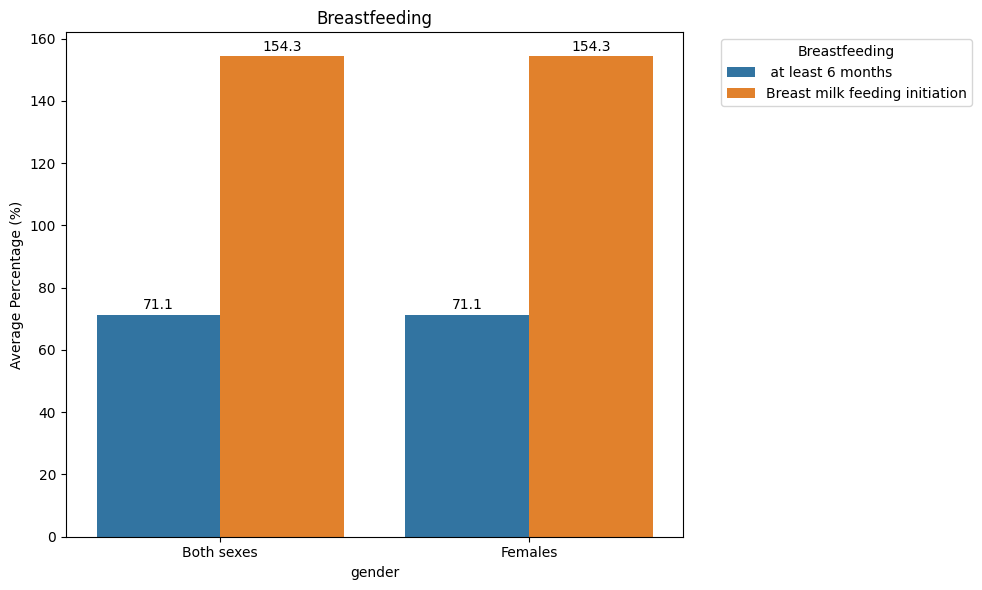

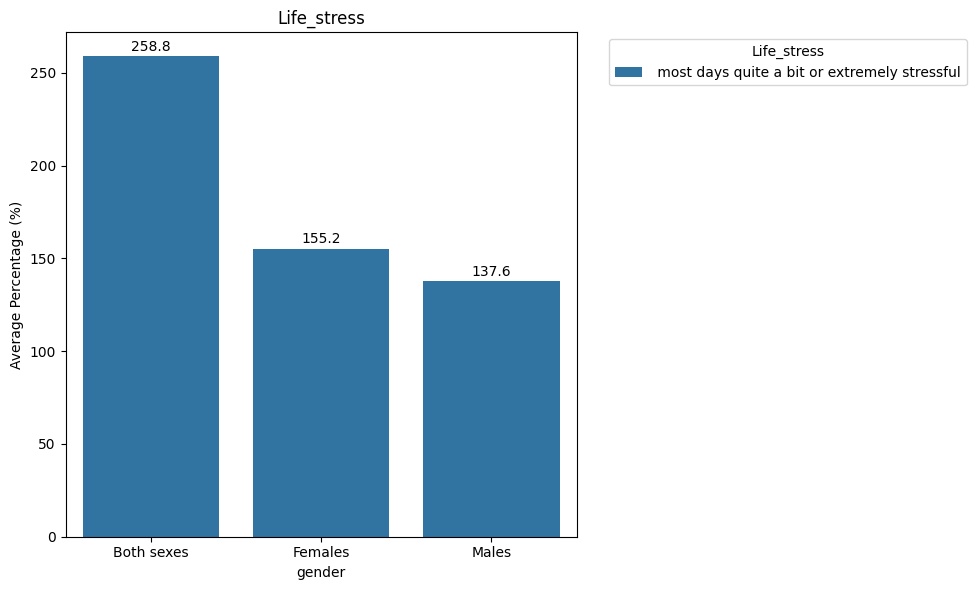

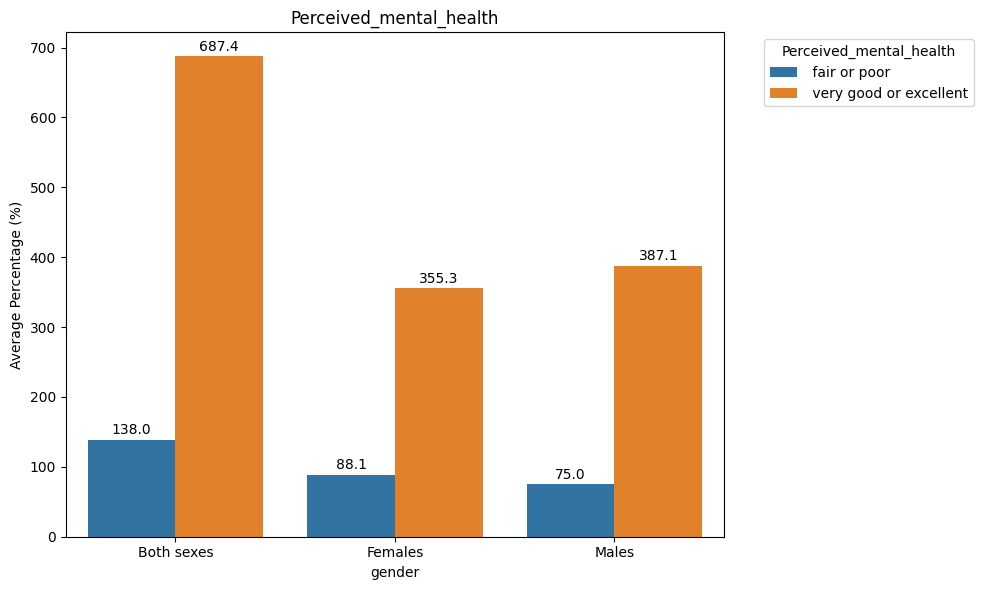

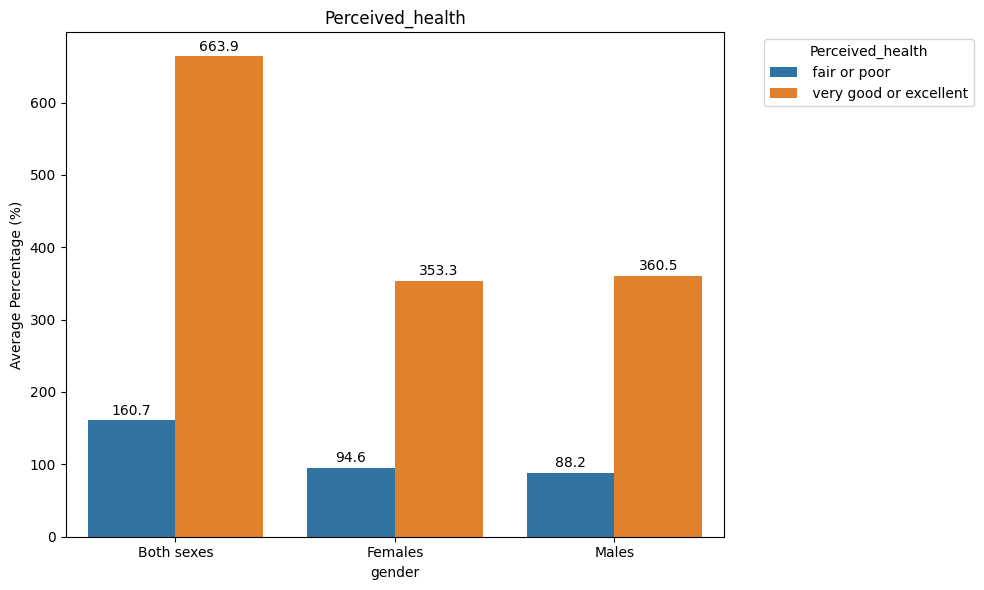

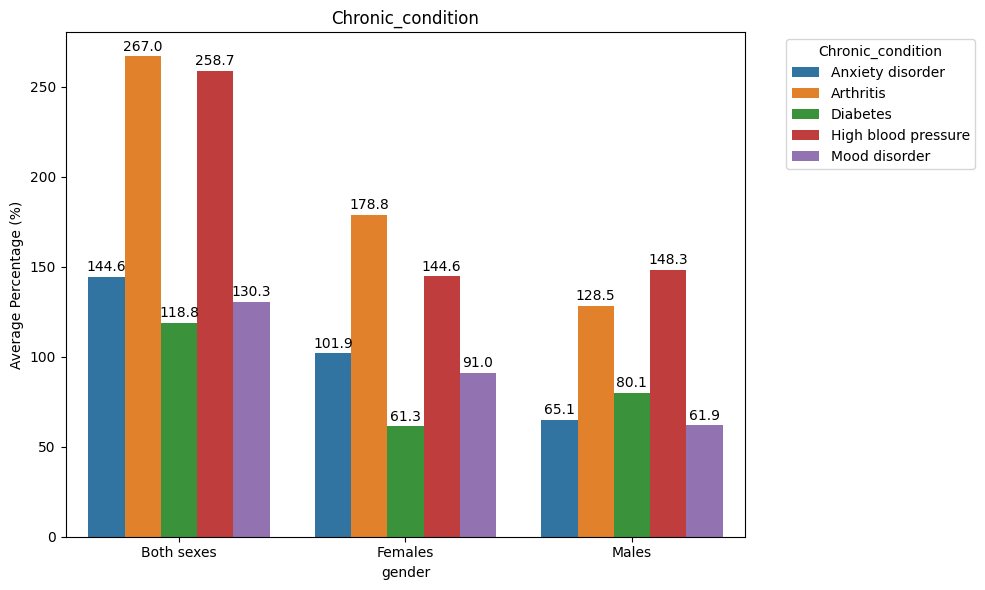

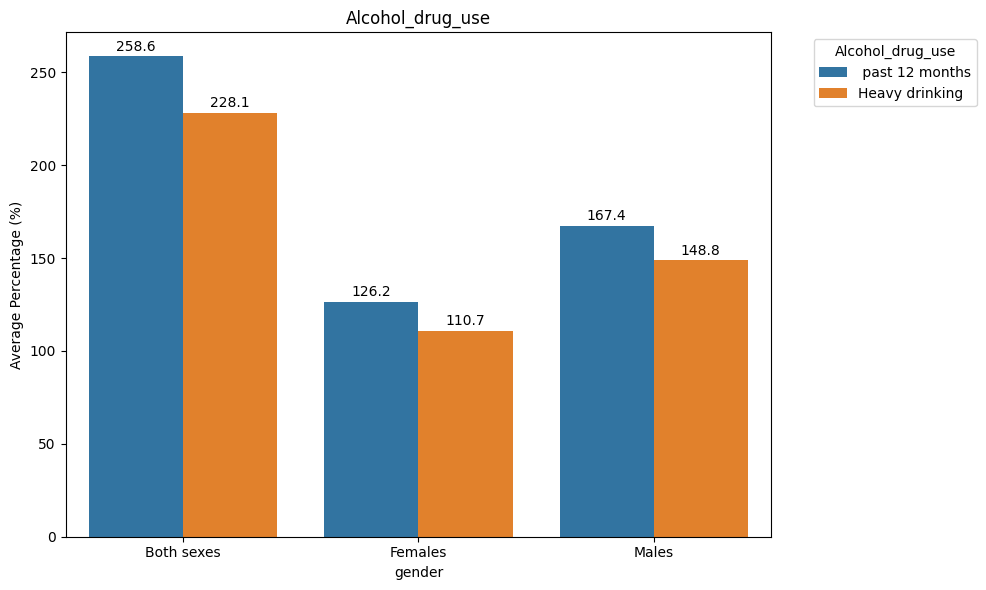

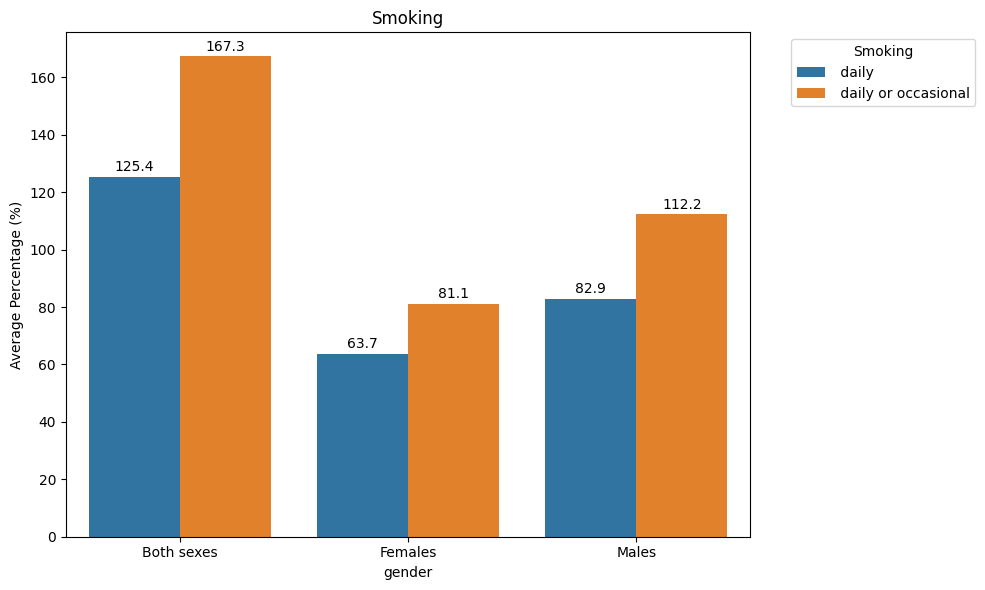

In [38]:
# Plot by Gender
for col in cols_to_plot:
    plot_bar_chart(df, 'gender', col, col, stacked_by=False)

# Plot by Geographic Location

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


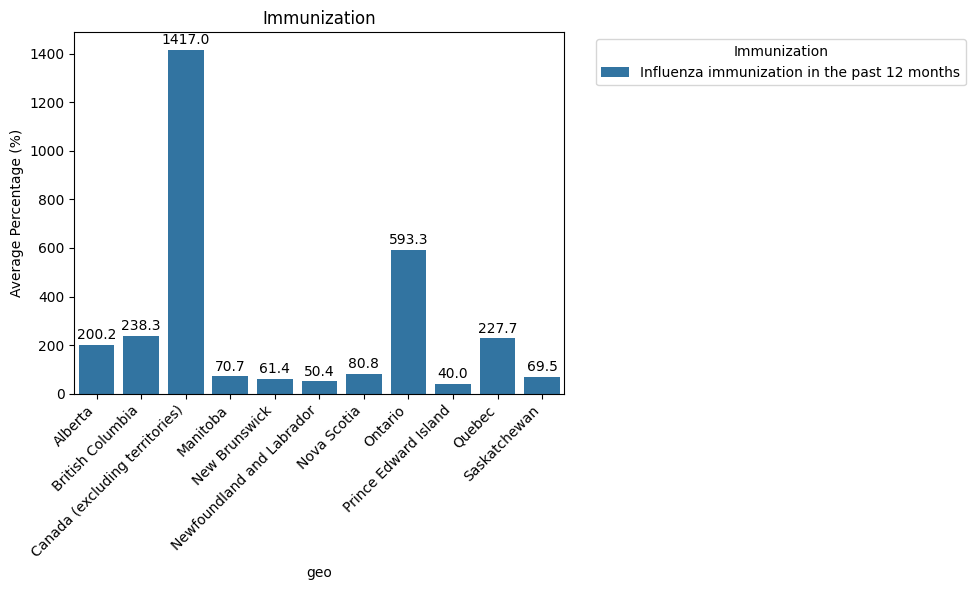

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


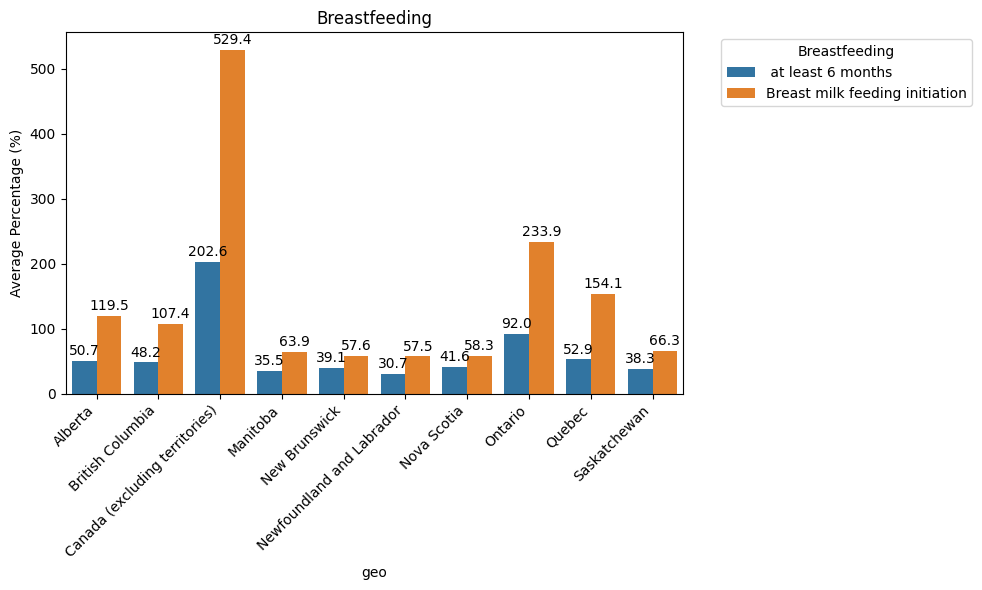

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


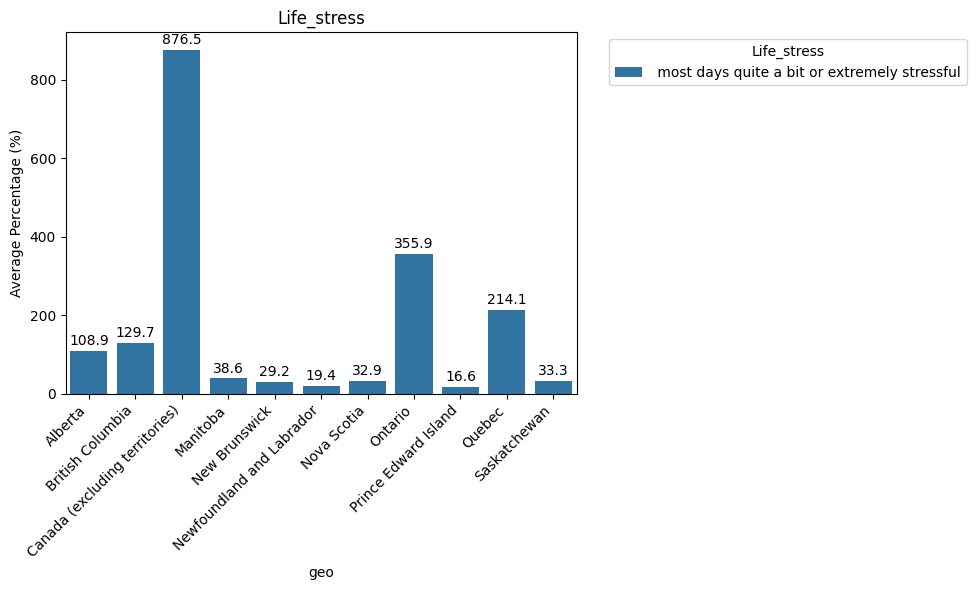

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


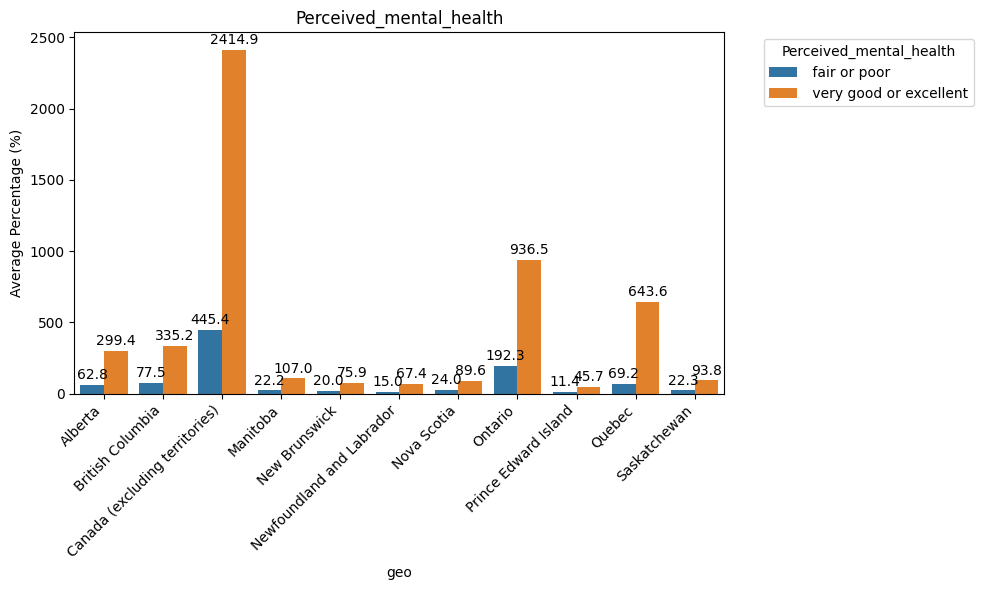

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


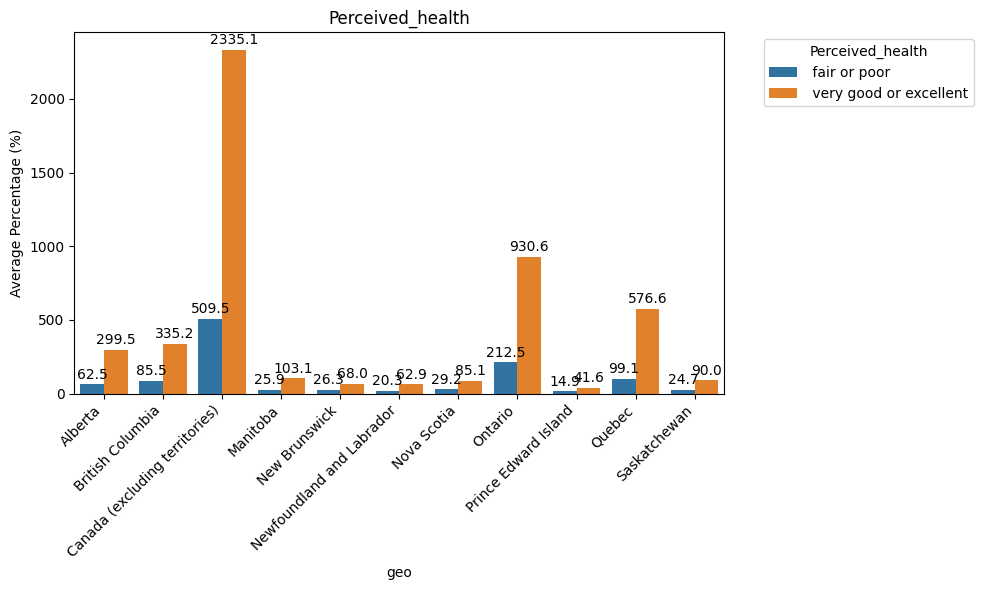

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


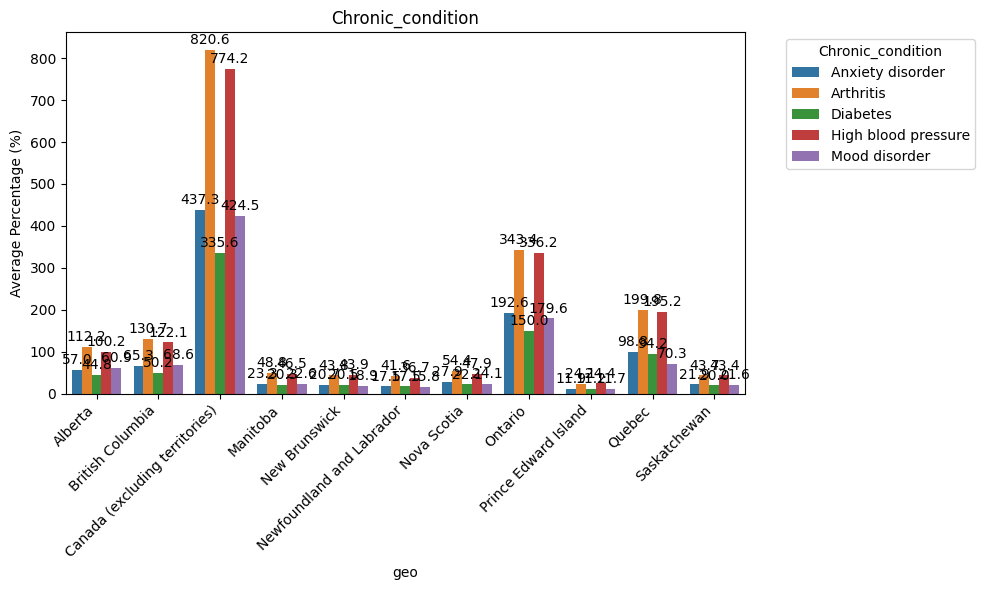

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


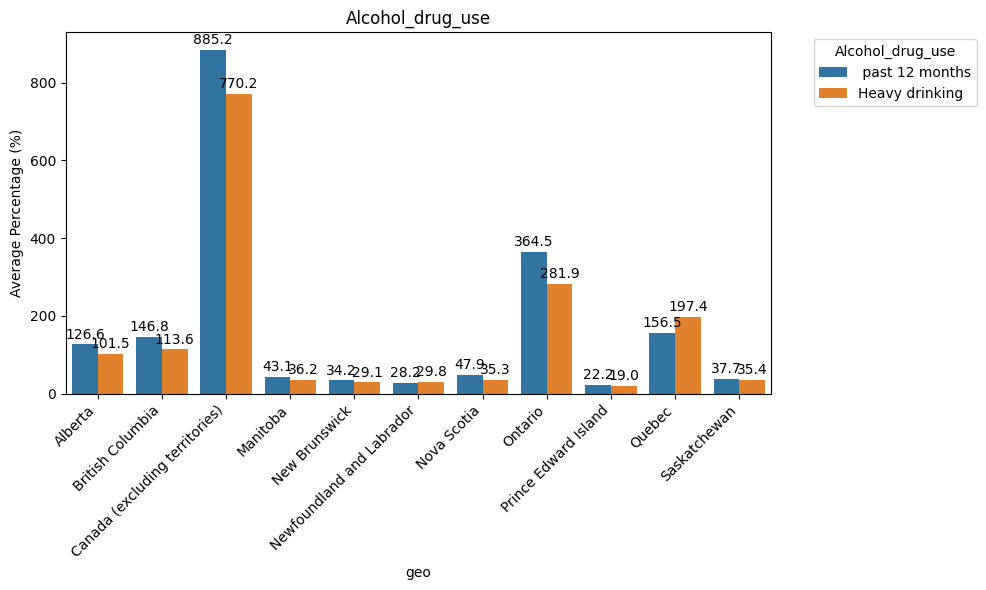

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_46003/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


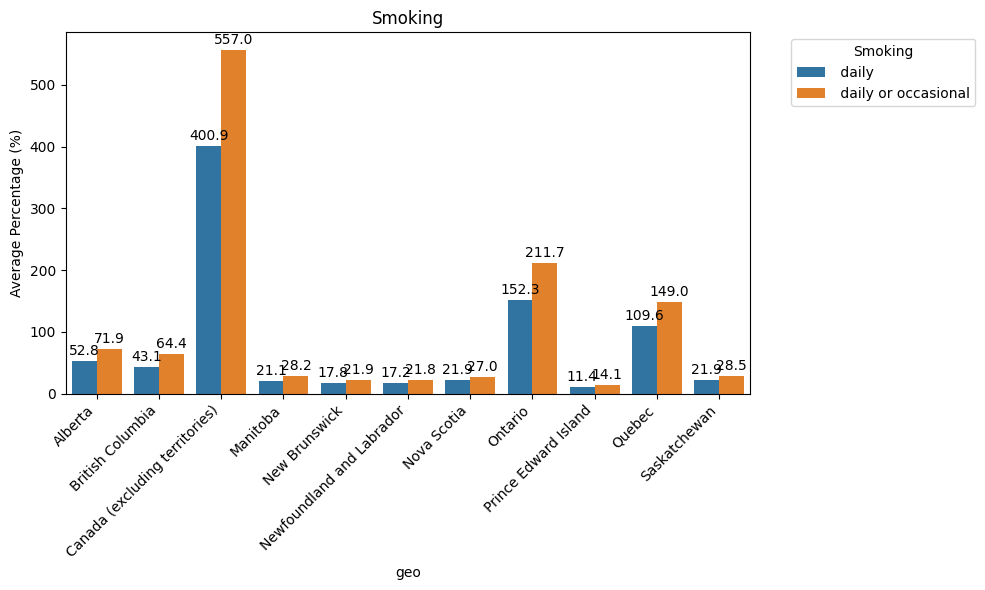

In [40]:
# Plot by Geographic Location
for col in cols_to_plot:
    plot_bar_chart(df, 'geo', col, col, stacked_by=False, rotate=45)